In [26]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt


In [27]:
df=pd.read_csv('C:/Users/TUSHITA NAHA/OneDrive/Documents/jupyter/MaunaLoaDailyTemps.csv', parse_dates=True)
df=df.dropna()
print('Shape of data',df.shape)
df.head()

Shape of data (1821, 6)


,DATE,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
0,1/1/2014,33.0,46.0,40.0,657,1756
1,1/2/2014,35.0,50.0,43.0,657,1756
2,1/3/2014,36.0,45.0,41.0,657,1757
3,1/4/2014,32.0,41.0,37.0,658,1757
4,1/5/2014,24.0,38.0,31.0,658,1758


<Axes: >

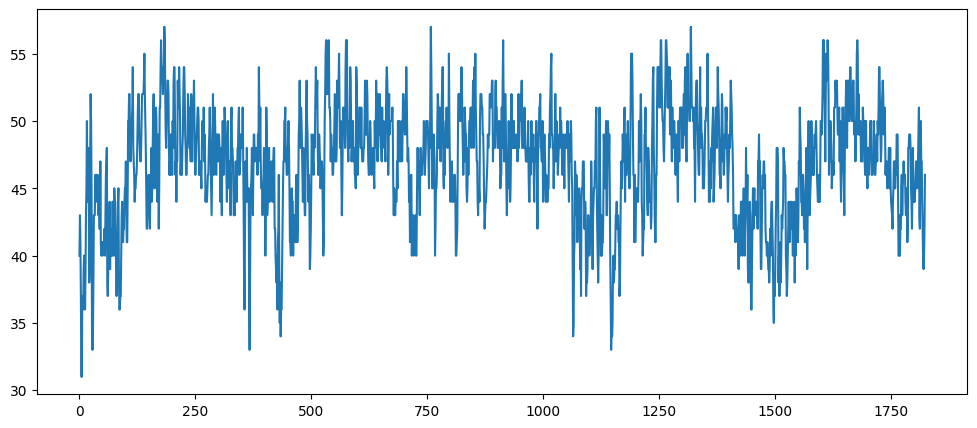

In [29]:
df['AvgTemp'].plot(figsize=(12,5))

In [30]:
#CHECK STATIONARITY
#IF P<0.05, DATA STATIONARY
#IF P>0.05, DATA NOT STATIONARY
from statsmodels.tsa.stattools import adfuller
def ad_test(dataset):
     dftest = adfuller(dataset, autolag = 'AIC')
     print("1. ADF : ",dftest[0])
     print("2. P-Value : ", dftest[1])
     print("3. Num Of Lags : ", dftest[2])
     print("4. Num Of Observations Used For ADF Regression:",      dftest[3])
     print("5. Critical Values :")
     for key, val in dftest[4].items():
         print("\t",key, ": ", val)
ad_test(df['AvgTemp'])

1. ADF :  -6.554680125068777
2. P-Value :  8.67593748019965e-09
3. Num Of Lags :  12
4. Num Of Observations Used For ADF Regression: 1808
5. Critical Values :
	 1% :  -3.433972018026501
	 5% :  -2.8631399192826676
	 10% :  -2.5676217442756872


In [31]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [32]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(df['AvgTemp'], trace=True,
suppress_warnings=True) #USES AIC SCORE TO DETERMINE GOOD OR NOT
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=8344.264, Time=2.52 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=10347.755, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=8365.701, Time=0.22 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9136.225, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19192.139, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=8355.947, Time=1.67 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=8356.308, Time=2.01 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=8347.291, Time=2.76 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=8318.476, Time=2.11 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=8330.188, Time=2.11 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=8311.105, Time=2.49 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=8331.879, Time=2.69 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=8317.653, Time=3.04 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=8307.162, Time=2.72 sec
 ARIMA(1,0,4)(0,0,0)[0] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1821
Model:               SARIMAX(1, 0, 5)   Log Likelihood               -4139.505
Date:                Tue, 16 Apr 2024   AIC                           8295.010
Time:                        21:12:49   BIC                           8339.067
Sample:                             0   HQIC                          8311.263
                               - 1821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2483      0.369      3.382      0.001       0.525       1.972
ar.L1          0.9731      0.008    122.358      0.000       0.958       0.989
ma.L1         -0.1261      0.024     -5.343      0.000      -0.172      -0.080
ma.L2         -0.2178      0.024     -9.069      0.000      -0.265      -0.171
ma.L3         -0.2036      0.024     -8.564      0.000      -0.250      -0.157
ma.L4         -0.1360      0.023     -6.006      0.000      -0.180      -0.092
ma.L5         -0.0481      0.024     -1.984      0.047      -0.096      -0.001
sigma2         5.4642      0.170     32.146      0.000       5.131       5.797
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                20.50
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.17
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
print(df.shape)
train=df.iloc[:-293]
test=df.iloc[-293:]
print(train.shape,test.shape)

(1821, 6)
(1528, 6) (293, 6)


In [34]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train['AvgTemp'],order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                 1528
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -3496.567
Date:                Tue, 16 Apr 2024   AIC                           7009.134
Time:                        21:13:42   BIC                           7051.788
Sample:                             0   HQIC                          7025.010
                               - 1528                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2354      0.909     50.862      0.000      44.454      48.017
ar.L1          0.9882      0.005    195.631      0.000       0.978       0.998
ma.L1         -0.1351      0.025     -5.432      0.000      -0.184      -0.086
ma.L2         -0.2382      0.025     -9.366      0.000      -0.288      -0.188
ma.L3         -0.2089      0.025     -8.266      0.000      -0.258      -0.159
ma.L4         -0.1594      0.025     -6.456      0.000      -0.208      -0.111
ma.L5         -0.0673      0.026     -2.548      0.011      -0.119      -0.016
sigma2         5.6845      0.194     29.304      0.000       5.304       6.065
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                14.27
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -0.16
Prob(H) (two-sided):                  0.63   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
start=len(train)
end=len(train)+len(test)-1
pred=model.predict(start=start,end=end,type='levels').rename('ARIMA Predictions')
pred.index=df.index[start:end+1]
print(pred)

1531    44.007550
1532    43.627861
1533    43.281729
1534    43.064911
1535    43.012818
          ...    
1820    46.125586
1821    46.126885
1822    46.128169
1823    46.129438
1824    46.130691
Name: ARIMA Predictions, Length: 293, dtype: float64


<Axes: >

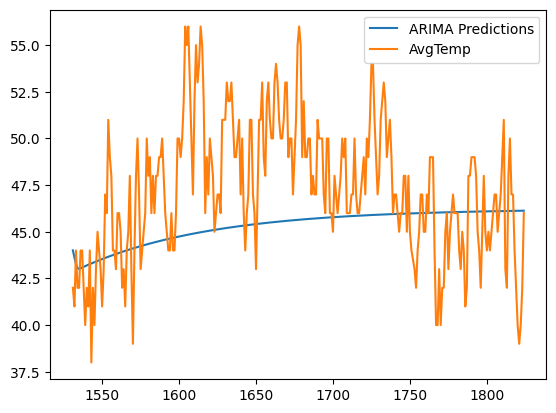

In [37]:
pred.plot(legend=True)
test['AvgTemp'].plot(legend=True)

In [39]:
from sklearn.metrics import mean_squared_error
from math import sqrt
test['AvgTemp'].mean()
rmse=sqrt(mean_squared_error(pred,test['AvgTemp']))
print(rmse)

4.04460112211968


In [42]:
forecast_data = df.rename(columns = {"DATE": "ds", 
                                       "AvgTemp": "y"})
print(forecast_data)

              ds  MinTemp  MaxTemp     y  Sunrise  Sunset
0       1/1/2014     33.0     46.0  40.0      657    1756
1       1/2/2014     35.0     50.0  43.0      657    1756
2       1/3/2014     36.0     45.0  41.0      657    1757
3       1/4/2014     32.0     41.0  37.0      658    1757
4       1/5/2014     24.0     38.0  31.0      658    1758
...          ...      ...      ...   ...      ...     ...
1820  12/26/2018     35.0     45.0  40.0      654    1752
1821  12/27/2018     33.0     44.0  39.0      655    1752
1822  12/28/2018     33.0     47.0  40.0      655    1753
1823  12/29/2018     36.0     47.0  42.0      655    1753
1824  12/30/2018     39.0     52.0  46.0      656    1754

[1821 rows x 6 columns]


In [43]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
model = Prophet()
model.fit(forecast_data)
forecasts = model.make_future_dataframe(periods = 365)
predictions = model.predict(forecasts)
plot_plotly(model, predictions)

21:14:46 - cmdstanpy - INFO - Chain [1] start processing
21:14:46 - cmdstanpy - INFO - Chain [1] done processing
